<a href="https://colab.research.google.com/github/priyal6/General-llm/blob/main/bf16%26fp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"

Torch version: 2.11.0+cu130
CUDA available: True


In [2]:
torch.manual_seed(42)

x = torch.randn(100_000, device=device) * 2

print("FP32")
print("min", x.min().item())
print("max", x.max().item())
print("mean:", x.mean().item())
print("std:", x.std().item())

FP32
min -8.79155158996582
max 8.282172203063965
mean: -0.006028969772160053
std: 1.9965413808822632


In [3]:
x_bf16 = x.to(torch.bfloat16)

print("\nBF16")
print("min:", x_bf16.min().item())
print("max:", x_bf16.max().item())


BF16
min: -8.8125
max: 8.3125


In [5]:
x_fp8 = x.to(torch.float8_e4m3fn)

print("\nFP8 E4M3")
print("min:", x_fp8.float().min().item())
print("max:", x_fp8.float().max().item())


FP8 E4M3
min: -9.0
max: 8.0


In [6]:
x_fp8.float()

tensor([ 0.3750,  4.5000, -0.3438,  ..., -0.7500,  2.5000, -1.5000],
       device='cuda:0')

In [7]:
bf16_reconstructed = x_bf16.float()
fp8_reconstructed = x_fp8.float()


bf16_error = (x - bf16_reconstructed).abs()
fp8_error = (x - fp8_reconstructed).abs()

print("BF16 mean absolute error:",
      bf16_error.mean().item())

print("FP8 mean absolute error:",
      fp8_error.mean().item())

print("BF16 max absolute error:",
      bf16_error.max().item())

print("FP8 max absolute error:",
      fp8_error.max().item())

BF16 mean absolute error: 0.0022451933473348618
FP8 mean absolute error: 0.0359465554356575
BF16 max absolute error: 0.030327796936035156
FP8 max absolute error: 0.36986541748046875


In [8]:
import torch.nn.functional as F

bf16_cos = F.cosine_similarity(
    x.flatten(),
    bf16_reconstructed.flatten(),
    dim=0
)

fp8_cos = F.cosine_similarity(
    x.flatten(),
    fp8_reconstructed.flatten(),
    dim=0
)

print("BF16 cosine similarity:", bf16_cos.item())
print("FP8 cosine similarity:", fp8_cos.item())

BF16 cosine similarity: 0.9999985694885254
FP8 cosine similarity: 0.9996476173400879


In [9]:
for i in range(20):
  print(
      f"Original: {x[i].item(): .8f} | "
      f"BF16: {bf16_reconstructed[i].item(): .8f} | "
      f"FP8: {fp8_reconstructed[i].item(): .8f}"
  )

Original:  0.38803759 | BF16:  0.38867188 | FP8:  0.37500000
Original:  4.32274723 | BF16:  4.31250000 | FP8:  4.50000000
Original: -0.34410045 | BF16: -0.34375000 | FP8: -0.34375000
Original:  1.69812024 | BF16:  1.69531250 | FP8:  1.75000000
Original: -3.84879804 | BF16: -3.84375000 | FP8: -3.75000000
Original:  1.30597103 | BF16:  1.30468750 | FP8:  1.25000000
Original: -1.29888165 | BF16: -1.29687500 | FP8: -1.25000000
Original: -1.63504946 | BF16: -1.63281250 | FP8: -1.62500000
Original:  1.05592895 | BF16:  1.05468750 | FP8:  1.00000000
Original: -2.55069971 | BF16: -2.54687500 | FP8: -2.50000000
Original: -3.32425261 | BF16: -3.32812500 | FP8: -3.25000000
Original: -0.60662746 | BF16: -0.60546875 | FP8: -0.62500000
Original: -0.18513975 | BF16: -0.18554688 | FP8: -0.18750000
Original:  0.39847431 | BF16:  0.39843750 | FP8:  0.40625000
Original: -2.24086571 | BF16: -2.23437500 | FP8: -2.25000000
Original:  3.71531725 | BF16:  3.71875000 | FP8:  3.75000000
Original: -1.42903769 | 

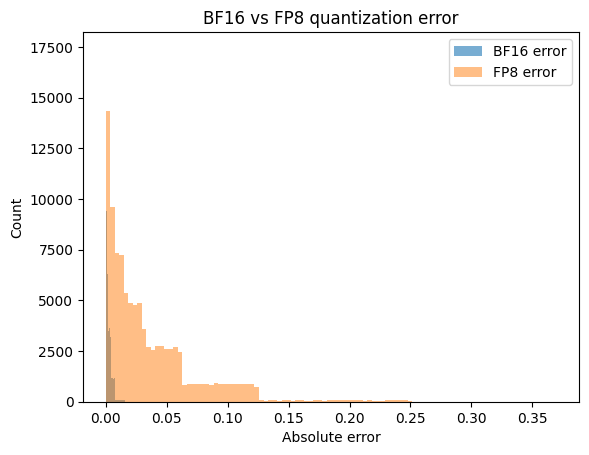

In [11]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(
    bf16_error.cpu().numpy(),
    bins=100,
    alpha=0.6,
    label="BF16 error"
)

plt.hist(
    fp8_error.cpu().numpy(),
    bins=100,
    alpha=0.5,
    label="FP8 error"
)

plt.xlabel("Absolute error")
plt.ylabel("Count")
plt.legend()
plt.title("BF16 vs FP8 quantization error")

plt.show()

In [12]:
x_range = torch.tensor([
    1e-8,
    1e-6,
    1e-4,
    1e-2,
    1.0,
    10.0,
    100.0,
    1000.0,
    10000.0
], device=device)

bf16 = x_range.to(torch.bfloat16).float()
fp8 = x_range.to(torch.float8_e4m3fn).float()

for original, b, f in zip(x_range, bf16, fp8):
    print(
        f"{original.item():>12g} | "
        f"BF16: {b.item():>12g} | "
        f"FP8: {f.item():>12g}"
    )

       1e-08 | BF16:  1.00117e-08 | FP8:            0
       1e-06 | BF16:  9.98378e-07 | FP8:            0
      0.0001 | BF16:  0.000100136 | FP8:            0
        0.01 | BF16:    0.0100098 | FP8:   0.00976562
           1 | BF16:            1 | FP8:            1
          10 | BF16:           10 | FP8:           10
         100 | BF16:          100 | FP8:           96
        1000 | BF16:         1000 | FP8:          nan
       10000 | BF16:         9984 | FP8:          nan


BF16 has an 8-bit exponent, so its dynamic range is huge.
FP8 E4M3 only has a 4-bit exponent, so sufficiently large values can become

In [18]:
fp8_e5m2 = x_range.to(torch.float8_e5m2).float()
print(fp8_e5m2.min().item())
print(torch.finfo(torch.float8_e5m2))

0.0
finfo(resolution=1, min=-57344, max=57344, eps=0.25, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float8_e5m2)


In [19]:
!pip install -q transformers

In [20]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B",
    torch_dtype=torch.float32
)

model = model.to(device)

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [21]:
for name, param in model.named_parameters():
  if "q_proj.weight" in name:
    weight = param.detach()
    print(name, weight.shape)
    break

model.layers.0.self_attn.q_proj.weight torch.Size([896, 896])


In [22]:
w_bf16 = weight.to(torch.bfloat16).float()
w_fp8 = weight.to(torch.float8_e4m3fn).float()

bf16_error = (weight - w_bf16).abs()
fp8_error = (weight - w_fp8).abs()

print("Original min/max:",
      weight.min().item(),
      weight.max().item())

print("BF16 MAE:",
      bf16_error.mean().item())

print("FP8 MAE:",
      fp8_error.mean().item())

Original min/max: -1.25 1.1953125
BF16 MAE: 0.0
FP8 MAE: 0.00106046034488827
